# Imports

In [1]:
import time
#import cv2
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
#import imutils
import matplotlib.image as mpimg
from collections import OrderedDict
import pandas as pd

from skimage import io, transform
from math import *
import xml.etree.ElementTree as ET 
import pandas as pd
from skimage.transform import AffineTransform, warp
from skimage.transform import rotate as rotate_transform
from skimage.util import random_noise
from skimage.filters import gaussian
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from torchvision import datasets, models, transforms
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from landmarks_datasets import LandmarksDataset, LandmarksMaskDataset
from landmarks_transforms import Transforms, UnNormalize
from skimage.segmentation import disk_level_set
torch.cuda.empty_cache()

In [2]:
disk_level_set(image_shape=(10,10), center=(5,5), radius=2)

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 1, 1, 0, 0, 0],
       [0, 0, 0, 0, 1, 1, 1, 0, 0, 0],
       [0, 0, 0, 0, 1, 1, 1, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], dtype=int8)

# Instantiate and check dataset
Plot a few samples with transforms enabled

In [3]:
DataSet = LandmarksMaskDataset(Transforms(), disk_radius=3)
# DataSet.NoTransF()

shgape1 (11, 224, 224)
shgape2 torch.Size([11, 224, 224])
11 torch.Size([224, 224]) <function amax at 0x7f6c1c048f70>


/home/josias/Documents/Tsetse Flies/Landmark-detection-for-tsetse-fly-wings/landmarks_datasets.py:200: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  landmarks = torch.tensor(landmarks) - 0.5


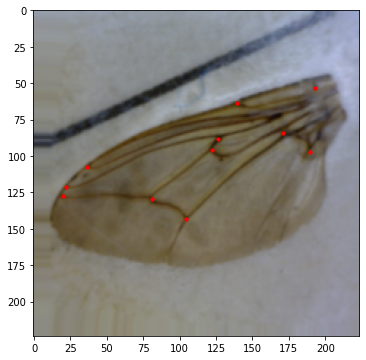

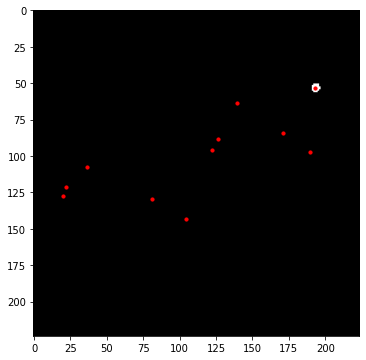

In [4]:
image_, landmarks, masks = DataSet[-1]
print(len(masks), masks[0].shape, np.amax)
unorm = UnNormalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
image = unorm(image_)

landmarks = (landmarks + 0.5) * torch.tensor([224, 224])
image = image_.permute(1, 2, 0).numpy()

plt.figure(figsize=(10,6))
plt.imshow(image)
plt.scatter(landmarks[:,0], landmarks[:,1], s=10, color ='r')
plt.figure(figsize=(10,6))
plt.imshow(masks[0], cmap="gray")
plt.scatter(landmarks[:,0], landmarks[:,1], s=10, color ='r')


In [4]:
class resnet50(nn.Module):
    def __init__(self,num_classes=22):
        super().__init__()
        self.model_name='resnet50'
        self.model=models.resnet50(pretrained=True)
        self.model.conv1=nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.model.fc=nn.Linear(self.model.fc.in_features, num_classes)
        
    def forward(self, x):
        x=self.model(x)
        return x

In [5]:
#DataSet.TransF()
#DataSet.resize(244)
dataset = DataSet
# split the dataset into validation and test sets
len_valid_test_set = int(0.2*len(dataset)) # 60% training, 20% validation, 20% testing

len_train_set = len(dataset) - len_valid_test_set*2

print("The length of Train set is {}".format(len_train_set))
print("The length of Valid set is {}".format(len_valid_test_set))
print("The length of Valid set is {}".format(len_valid_test_set))

train_dataset , valid_dataset, test_dataset  = torch.utils.data.random_split(dataset , [len_train_set, len_valid_test_set, len_valid_test_set], generator=torch.Generator().manual_seed(42))

# shuffle and batch the datasets
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=50, shuffle=True)
valid_loader = torch.utils.data.DataLoader(valid_dataset, batch_size=50, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=10, shuffle=True)



The length of Train set is 1452
The length of Valid set is 484
The length of Valid set is 484


In [6]:
# helper functions
import sys
import pickle

def print_overwrite(step, total_step, loss, operation):
    sys.stdout.write('\r')
    if operation == 'train':
        sys.stdout.write("Train Steps: %d/%d  Loss: %.8f " % (step, total_step, loss))   
    else:
        sys.stdout.write("Valid Steps: %d/%d  Loss: %.8f " % (step, total_step, loss))
        
    sys.stdout.flush()